In [4]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import scipy as scp
import multiprocessing

In [5]:
df = pd.read_csv("Final_Simulations_Coverage_Probability_2.csv")


In [6]:
df

,Unnamed: 0,cov_prob1,cov_prob10,cov_prob100,cov_prob1000,cov_prob10000,Design,Corr,CI,idx
0,0,0.9802,0.9854,0.9776,0.9775,0.9777,1,Simple,LS2,0
1,0,0.9790,0.9889,0.9910,0.9913,0.9911,1,Simple,P,0
2,0,0.9712,0.9818,0.9775,0.9778,0.9777,1,Simple,TS,0
3,0,0.9794,0.9895,0.9795,0.9760,0.9760,1,Simple,zoom,0
4,1,0.9863,0.9872,0.9790,0.9782,0.9789,1,Low,LS2,1
5,1,0.9852,0.9892,0.9893,0.9891,0.9894,1,Low,P,1
6,1,0.9833,0.9830,0.9790,0.9782,0.9783,1,Low,TS,1
7,1,0.9854,0.9893,0.9813,0.9768,0.9768,1,Low,zoom,1
8,2,0.9885,0.9886,0.9811,0.9766,0.9768,1,Med,LS2,2
9,2,0.9874,0.9880,0.9885,0.9890,0.9884,1,Med,P,2


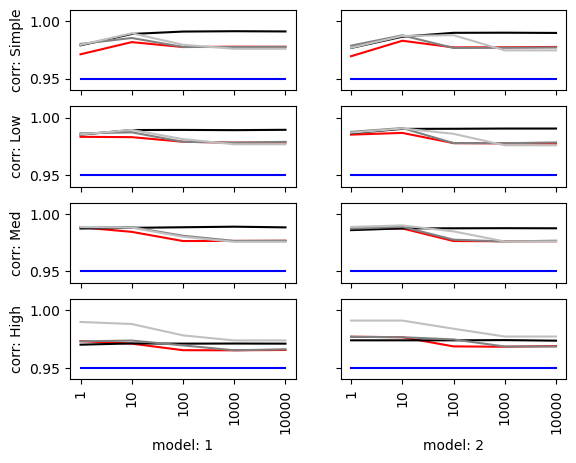

In [7]:
design_mat = [[1,2],
              [1,2],
              [1,2],
              [1,2]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
        axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
        axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row,col].set_ylim([0.94,1.01])
        
        axes[row,col].set_ylabel("corr: " + corr_t)
        
        axes[row,col].set_xlabel("model: " + str(col+1))
        
for ax in fig.get_axes():
    ax.label_outer()

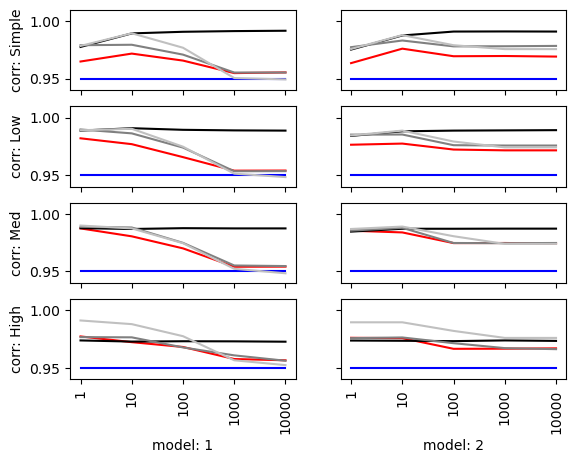

In [60]:
design_mat = [[1,5],
              [1,5],
              [1,5],
              [1,5]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
        axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
        axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row,col].set_ylim([0.94,1.01])
        
        axes[row,col].set_ylabel("corr: " + corr_t)
        
        axes[row,col].set_xlabel("model: " + str(col+1))
        
for ax in fig.get_axes():
    ax.label_outer()

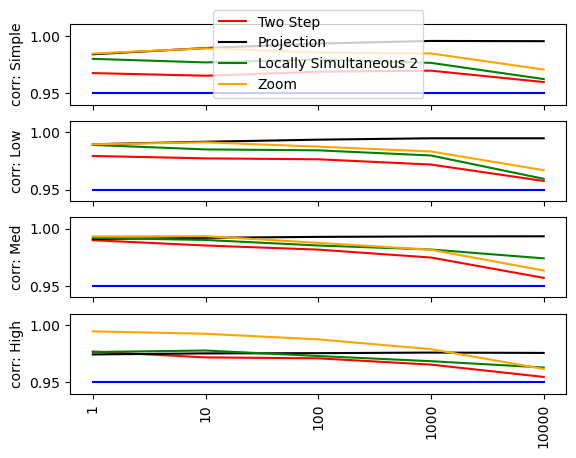

In [18]:
design_mat = [[2],
              [2],
              [2],
              [2]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

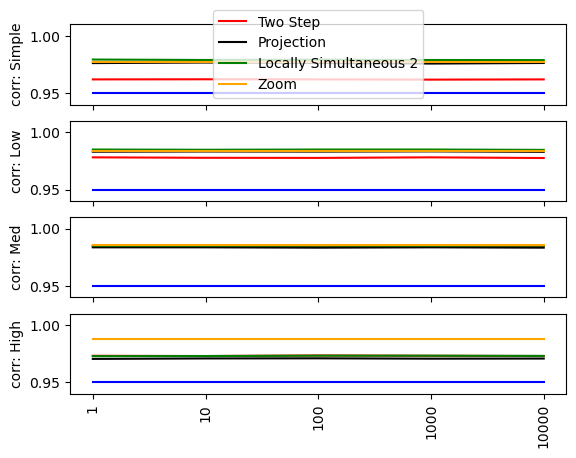

In [19]:
design_mat = [[3],
              [3],
              [3],
              [3]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

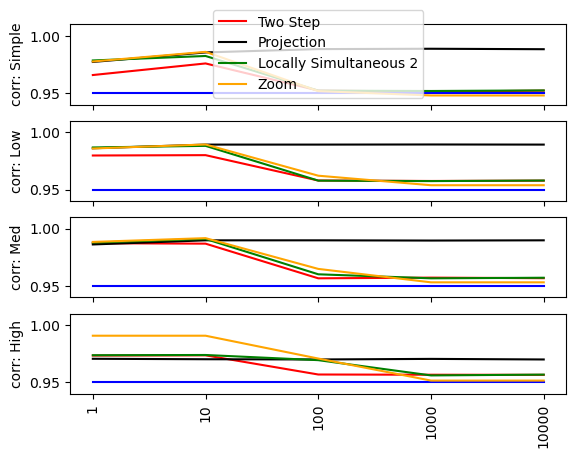

In [20]:
design_mat = [[4],
              [4],
              [4],
              [4]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

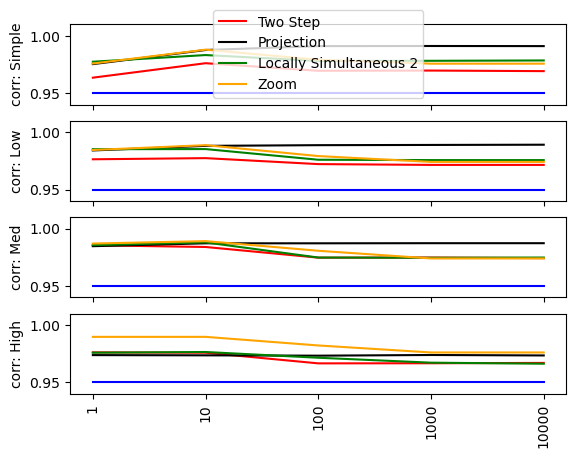

In [21]:
design_mat = [[5],
              [5],
              [5],
              [5]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

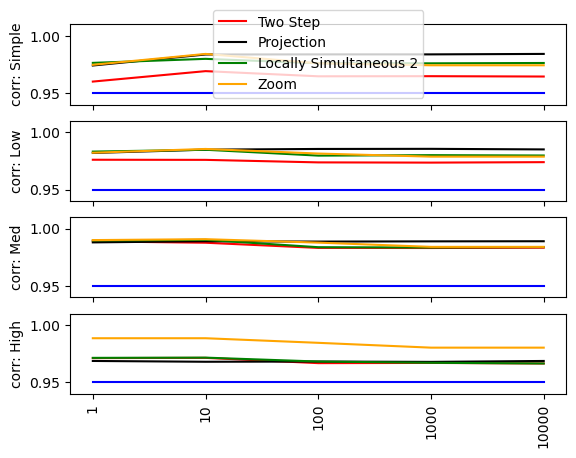

In [22]:
design_mat = [[6],
              [6],
              [6],
              [6]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

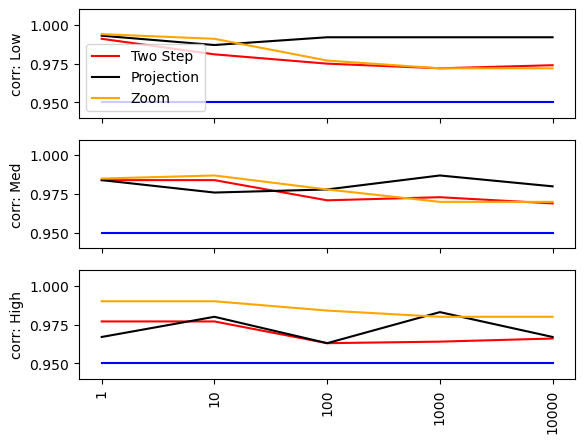

In [10]:
design_mat = [[7],
              [7],
              [7]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

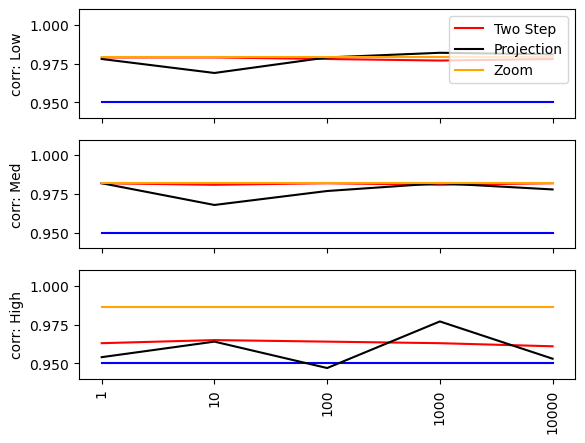

In [11]:
design_mat = [[8],
              [8],
              [8]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

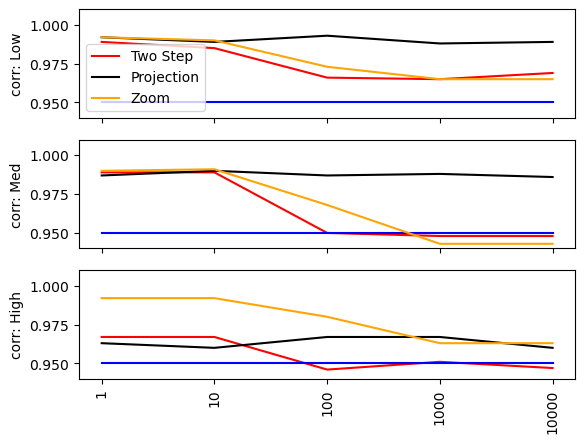

In [12]:
design_mat = [[9],
              [9],
              [9]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

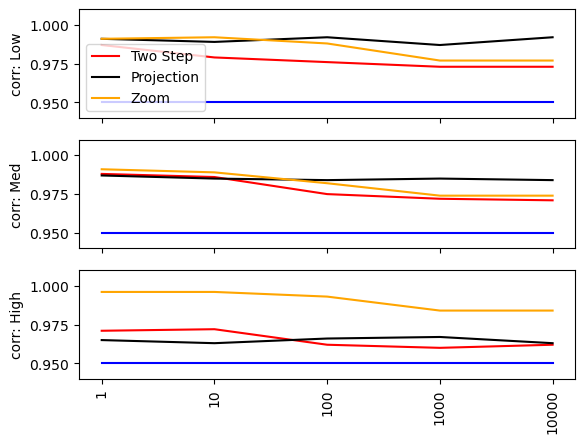

In [13]:
design_mat = [[10],
              [10],
              [10]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

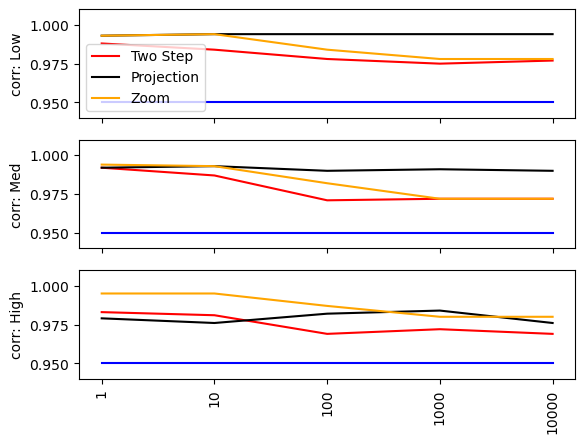

In [14]:
design_mat = [[11],
              [11],
              [11]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
        axes[row].plot([0.95 for i in range(5)], label="", color = "blue")
        axes[row].plot(np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        axes[row].set_ylim([0.94,1.01])
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

In [8]:
df = pd.read_csv("Final_Simulations_Length.csv")

In [9]:
df

,Unnamed: 0,length1,length10,length100,length1000,length10000,Design,Corr,CI,idx
0,0,5.205191,1.542886,0.451424,0.126790,0.040086,1.0,Simple,LS2,0
1,0,5.136787,1.624474,0.513703,0.162438,0.051372,1.0,Simple,P,0
2,0,4.814402,1.444901,0.429401,0.126750,0.040088,1.0,Simple,TS,0
3,0,5.152740,1.568976,0.448363,0.127611,0.039199,1.0,Simple,zoom,0
4,1,5.204311,1.544679,0.451375,0.126767,0.040077,1.0,Low,LS2,1
...,...,...,...,...,...,...,...,...,...,...
107,26,5.151659,1.627327,0.504544,0.157969,0.049954,7.0,Med,zoom,26
108,27,4.473372,1.414748,0.443682,0.139744,0.044187,7.0,High,LS2,27
109,27,4.385348,1.386861,0.438586,0.138690,0.043860,7.0,High,P,27
110,27,4.470844,1.413852,0.441862,0.139702,0.044189,7.0,High,TS,27


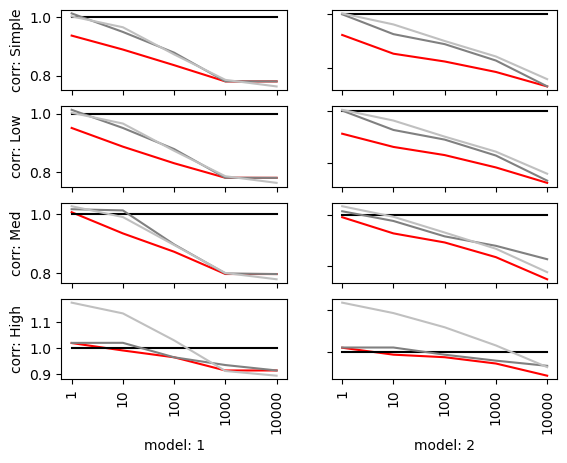

In [10]:
design_mat = [[1,2],
              [1,2],
              [1,2],
              [1,2]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
        axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
        axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        
        axes[row,col].set_ylabel("corr: " + corr_t)
        axes[row,col].set_xlabel("model: " + str(col+1))
        
for ax in fig.get_axes():
    ax.label_outer()

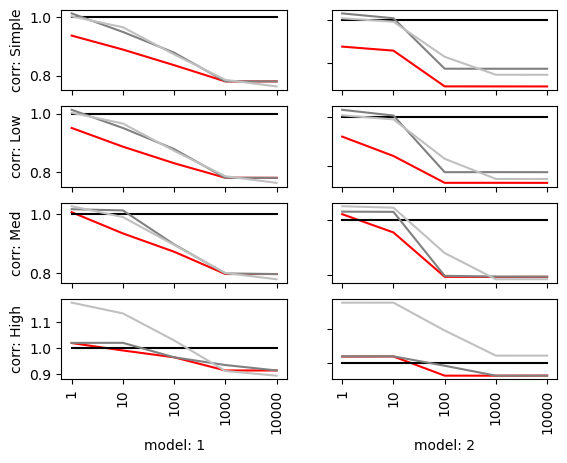

In [56]:
design_mat = [[1,5],
              [1,5],
              [1,5],
              [1,5]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
        axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
        axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        
        axes[row,col].set_ylabel("corr: " + corr_t)
        axes[row,col].set_xlabel("model: " + str(col+1))
        
for ax in fig.get_axes():
    ax.label_outer()

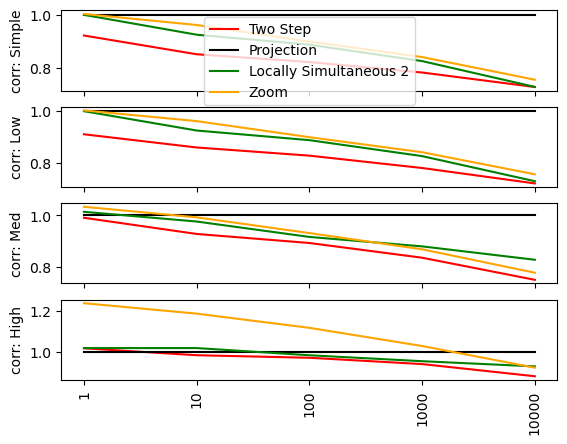

In [55]:
design_mat = [[2],
              [2],
              [2],
              [2]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

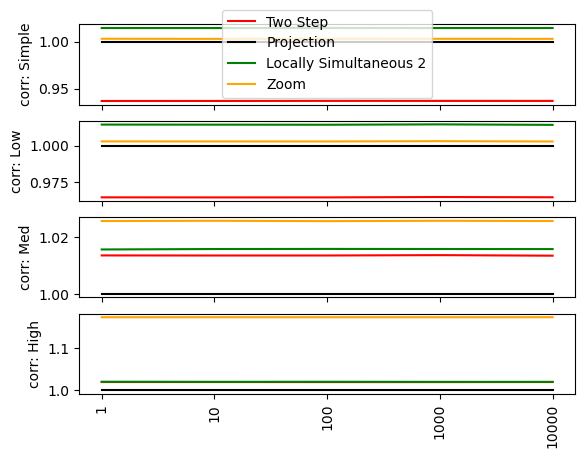

In [31]:
design_mat = [[3],
              [3],
              [3],
              [3]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

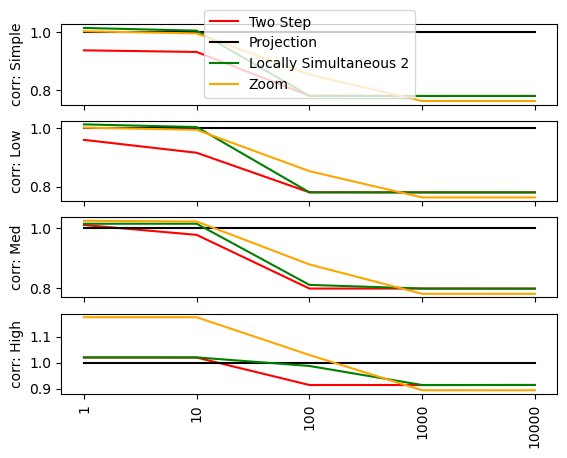

In [32]:
design_mat = [[4],
              [4],
              [4],
              [4]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

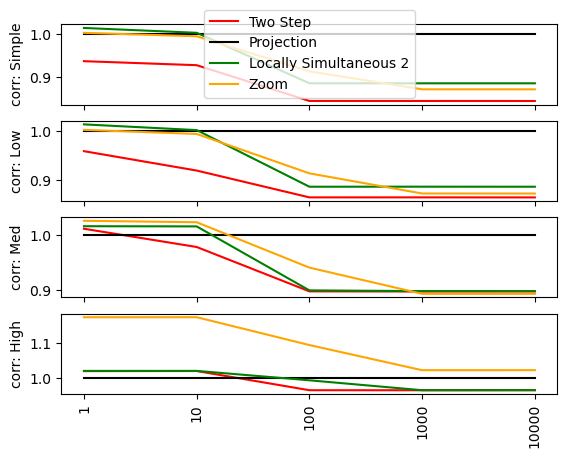

In [33]:
design_mat = [[5],
              [5],
              [5],
              [5]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

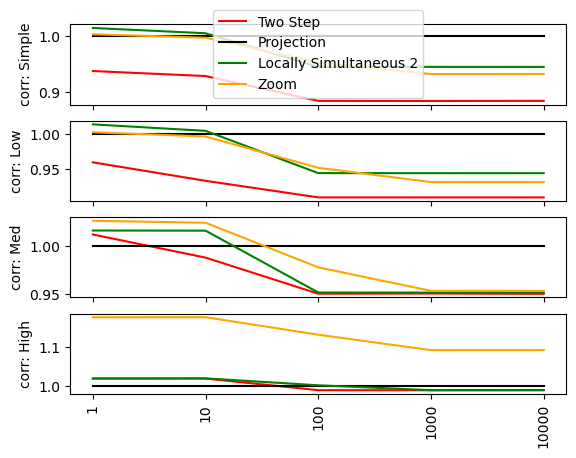

In [34]:
design_mat = [[6],
              [6],
              [6],
              [6]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 1)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        # LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        # LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        axes[row].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

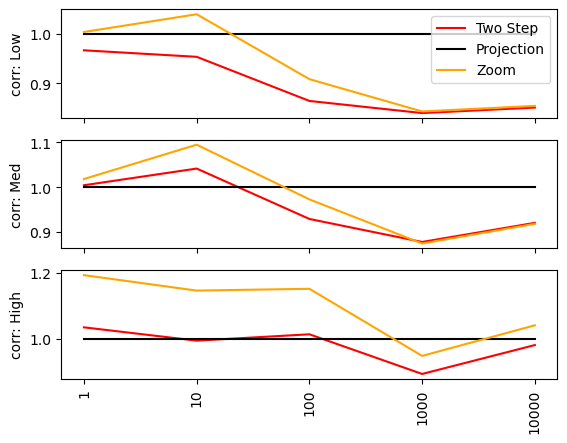

In [35]:
design_mat = [[7],
              [7],
              [7]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

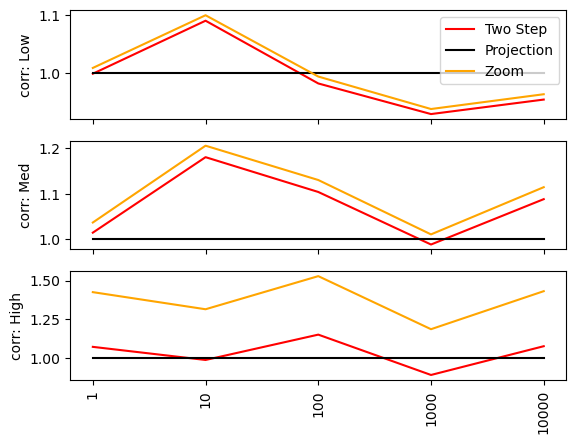

In [36]:
design_mat = [[8],
              [8],
              [8]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

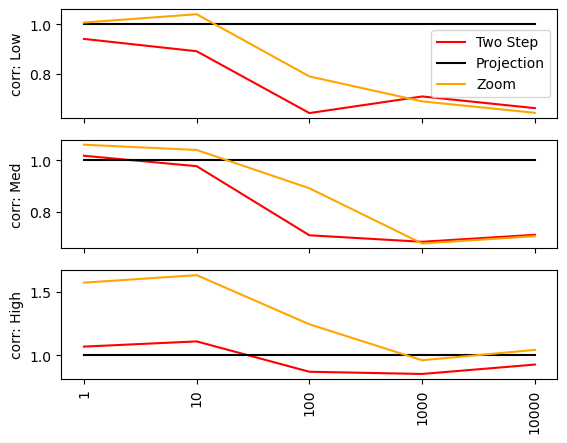

In [37]:
design_mat = [[9],
              [9],
              [9]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

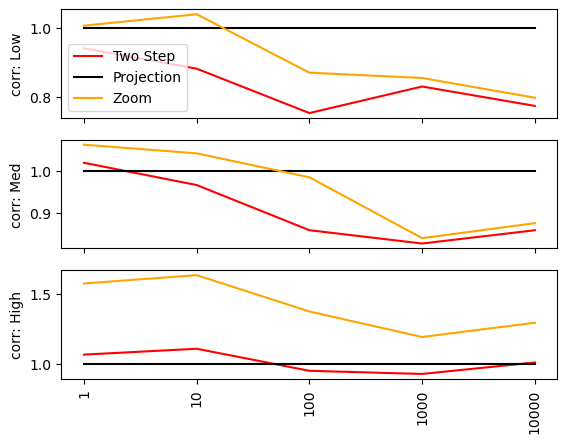

In [38]:
design_mat = [[10],
              [10],
              [10]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

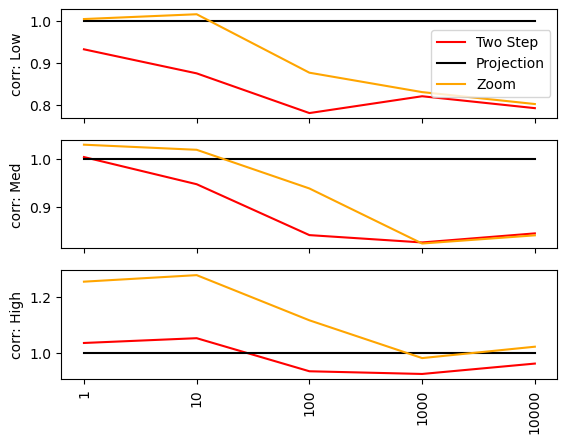

In [39]:
design_mat = [[11],
              [11],
              [11]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(3, 1)

corr = ["Low", "Med", "High"]

for row in range(3):
    for col in range(1):
        
        d = design_mat[row, col]
        
        corr_t = corr[row]
        
        bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
        bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
        bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
        bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
        bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))
        
        p_cov_prob = df.loc[bool_p]
        shaikh_cov_prob = df.loc[bool_shaikh]
        LS1_cov_prob = df.loc[bool_LS1]
        LS2_cov_prob = df.loc[bool_LS2]
        zoom_cov_prob = df.loc[bool_zoom]
        
        p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
        
        p_cov_prob = np.array(p_cov_prob)[0]
        shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
        LS1_cov_prob = np.array(LS1_cov_prob)[0]
        LS2_cov_prob = np.array(LS2_cov_prob)[0]
        zoom_cov_prob = np.array(zoom_cov_prob)[0]
        
        axes[row].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
        axes[row].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
        # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
        # axes[row].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "green")
        axes[row].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "orange")
        axes[row].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
        if row == 0:
            axes[row].legend()
        
        axes[row].set_ylabel("corr: " + corr_t)
        
for ax in fig.get_axes():
    ax.label_outer()

In [62]:
df_CI = pd.read_csv("Final_Simulations_Coverage_Probability.csv")
df_length = pd.read_csv("Final_Simulations_Length.csv")


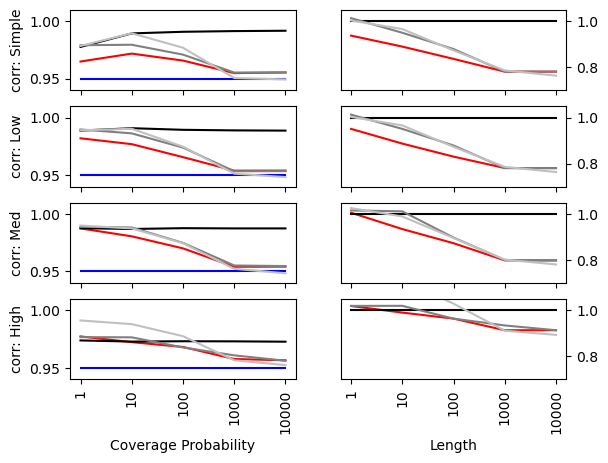

In [95]:
design_mat = [[1,1],
              [1,1],
              [1,1],
              [1,1]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_1_penultimate.png", dpi=300, bbox_inches="tight")


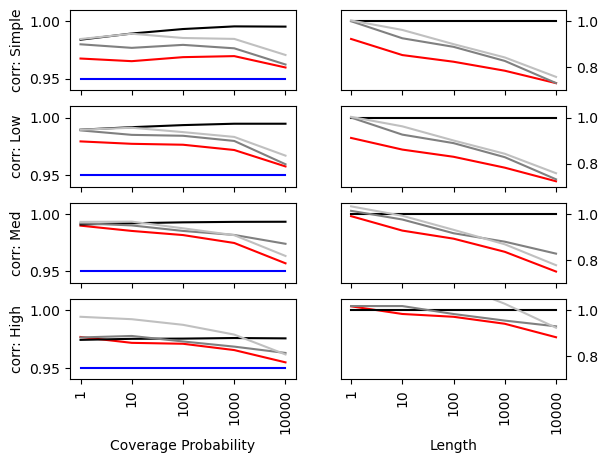

In [96]:
design_mat = [[2,2],
              [2,2],
              [2,2],
              [2,2]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_2_penultimate.png", dpi=300, bbox_inches="tight")


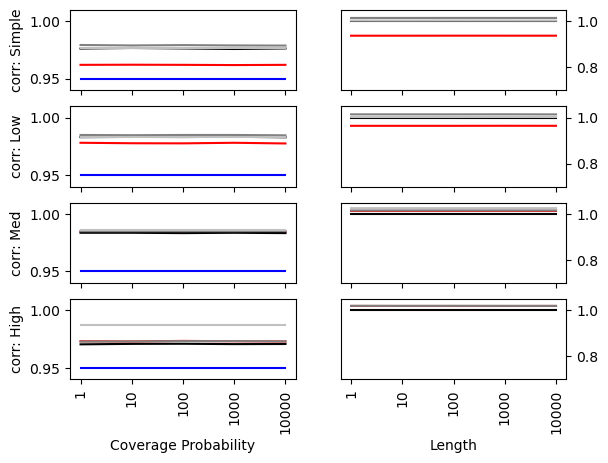

In [97]:
design_mat = [[3,3],
              [3,3],
              [3,3],
              [3,3]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_3_penultimate.png", dpi=300, bbox_inches="tight")
    

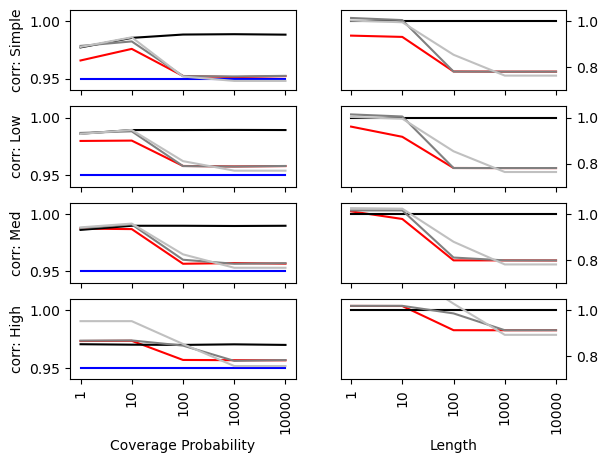

In [98]:
design_mat = [[4,4],
              [4,4],
              [4,4],
              [4,4]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_4_penultimate.png", dpi=300, bbox_inches="tight")


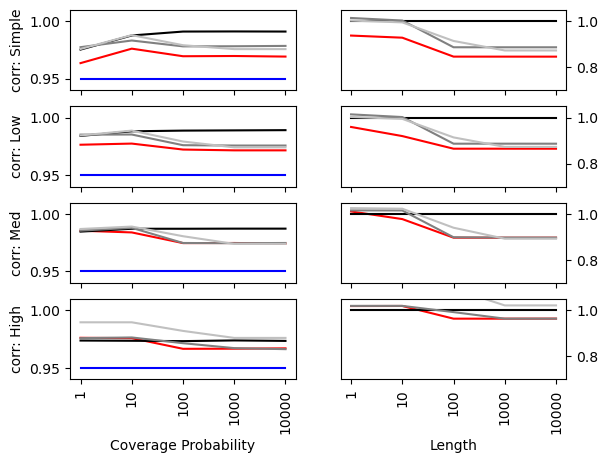

In [99]:
design_mat = [[5,5],
              [5,5],
              [5,5],
              [5,5]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_5_penultimate.png", dpi=300, bbox_inches="tight")


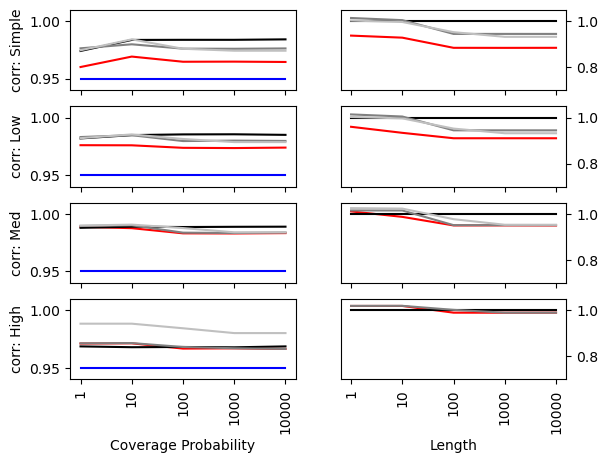

In [100]:
design_mat = [[6,6],
              [6,6],
              [6,6],
              [6,6]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

            
        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_6_penultimate.png", dpi=300, bbox_inches="tight")
    

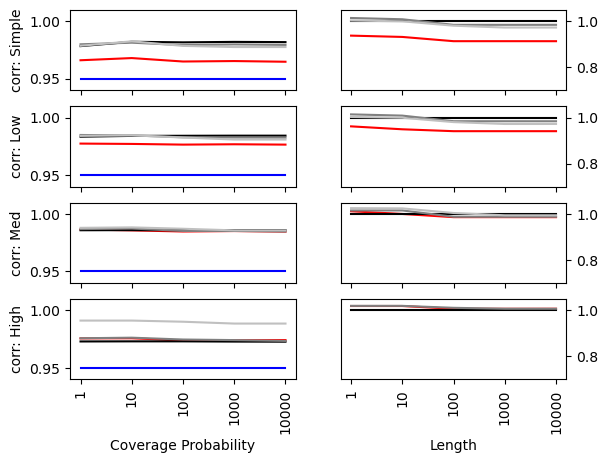

In [101]:
design_mat = [[7,7],
              [7,7],
              [7,7],
              [7,7]]

design_mat = np.array(design_mat)

fig, axes = plt.subplots(4, 2)

corr = ["Simple", "Low", "Med", "High"]

for row in range(4):
    for col in range(2):
        
        if col == 0:
            
            df = df_CI
        
            d = design_mat[row, col]

            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            # bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            # LS1_cov_prob = LS1_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            LS2_cov_prob = LS2_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]
            zoom_cov_prob = zoom_cov_prob[["cov_prob1", "cov_prob10", "cov_prob100", "cov_prob1000", "cov_prob10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot([0.95 for i in range(5)], label="", color = "blue")
            axes[row,col].plot(np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.94,1.01])

            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Coverage Probability")

        if col == 1:
            
            df = df_length

            d = design_mat[row, col]
        
            corr_t = corr[row]

            bool_p = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "P"))
            bool_shaikh = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "TS"))
            bool_LS1 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS1"))
            bool_LS2 = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "LS2"))
            bool_zoom = ((df["Design"] == d) & (df["Corr"] == corr_t) & (df["CI"] == "zoom"))

            p_cov_prob = df.loc[bool_p]
            shaikh_cov_prob = df.loc[bool_shaikh]
            # LS1_cov_prob = df.loc[bool_LS1]
            LS2_cov_prob = df.loc[bool_LS2]
            zoom_cov_prob = df.loc[bool_zoom]

            p_cov_prob = p_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            shaikh_cov_prob = shaikh_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            # LS1_cov_prob = LS1_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            LS2_cov_prob = LS2_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]
            zoom_cov_prob = zoom_cov_prob[["length1", "length10", "length100", "length1000", "length10000"]]

            p_cov_prob = np.array(p_cov_prob)[0]
            shaikh_cov_prob = np.array(shaikh_cov_prob)[0]
            # LS1_cov_prob = np.array(LS1_cov_prob)[0]
            LS2_cov_prob = np.array(LS2_cov_prob)[0]
            zoom_cov_prob = np.array(zoom_cov_prob)[0]

            axes[row,col].plot(np.array([i for i in range(5)]), np.array(shaikh_cov_prob) / np.array(p_cov_prob), label="Two Step", color = "red")
            axes[row,col].plot(np.array(p_cov_prob) / np.array(p_cov_prob), label="Projection", color = "black")
            # axes[row].plot(np.array(LS1_cov_prob), label="Locally Simultaneous 1", color = "gray")
            axes[row,col].plot(np.array(LS2_cov_prob) / np.array(p_cov_prob), label="Locally Simultaneous 2", color = "gray")
            axes[row,col].plot(np.array(zoom_cov_prob) / np.array(p_cov_prob), label="Zoom", color = "silver")
            axes[row,col].set_xticks([i for i in range(5)], [10 ** i for i in range(5)], rotation='vertical')
            axes[row,col].set_ylim([0.70,1.05])
            
            axes[row,col].set_ylabel("corr: " + corr_t)
            axes[row,col].set_xlabel("Length")
            
            axes[row, col].tick_params(axis="y", which="both", labelleft=True, labelright=True)
            axes[row, col].yaxis.tick_right()  
            axes[row, col].yaxis.set_major_locator(plt.MaxNLocator(nbins=2))
        
for ax in fig.get_axes():
    ax.label_outer()
    
plt.savefig("penultimate_study/design_7_penultimate.png", dpi=300, bbox_inches="tight")

    